In [36]:
import pandas as pd
df=pd.read_csv('Salary_Data.csv')
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [37]:
# Slice the dataset as descriptive (independent)and
# target varible (dependent)
X=df.iloc[:,0].values
Y=df.iloc[:,-1].values
print(X)
print(Y)

[ 1.1  1.3  1.5  2.   2.2  2.9  3.   3.2  3.2  3.7  3.9  4.   4.   4.1
  4.5  4.9  5.1  5.3  5.9  6.   6.8  7.1  7.9  8.2  8.7  9.   9.5  9.6
 10.3 10.5]
[ 39343.  46205.  37731.  43525.  39891.  56642.  60150.  54445.  64445.
  57189.  63218.  55794.  56957.  57081.  61111.  67938.  66029.  83088.
  81363.  93940.  91738.  98273. 101302. 113812. 109431. 105582. 116969.
 112635. 122391. 121872.]


In [38]:
# Splitting the dataset into training set and testing set
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=1/3,random_state=0)
print(df.shape)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(30, 2)
(20,)
(10,)
(20,)
(10,)


In [39]:
#Calculate the mean values of i/p and o/p
import numpy as np
x_mean=np.mean(X_train)
y_mean=np.mean(Y_train)
print(x_mean,y_mean)

4.7299999999999995 71022.5


In [40]:
# calculate intercept and coefficient
n=len(X_train)
num,den=0,0

for i in range(n):
  num+=(X_train[i]-x_mean)*(Y_train[i]-y_mean)
  den+=(X_train[i]-x_mean)**2
b1=num/den
b0=y_mean-(b1*x_mean)
print("b0:",b0)

b0: 26816.19224403117


In [41]:
# Predicting results on test dataset
y_pred_code=b0+b1*X_test
print(y_pred_code)

[ 40835.10590871 123079.39940819  65134.55626083  63265.36777221
 115602.64545369 108125.8914992  116537.23969801  64199.96201652
  76349.68719258 100649.1375447 ]


In [42]:
print(Y_test)

[ 37731. 122391.  57081.  63218. 116969. 109431. 112635.  55794.  83088.
 101302.]


In [43]:
# MEAN SQAURE ERROR (MSE)
n1=len(Y_test)
mse=0
for i in range(n1):
    mse+=(Y_test[i]-y_pred_code[i])**2

    mse=mse/n1
print(mse)


568874.0286162288


In [44]:
# root mean square error (MSE)
rmse=np.sqrt(mse)
print(rmse)

754.2373821392233


In [45]:
# create an object of an algorithm/model
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()

In [46]:
# Reshape X and fit the model to define intercept_ and coef_
regressor.fit(X_train.reshape(-1, 1), Y_train)

print("Intercept", regressor.intercept_)
print("Coefficient", regressor.coef_)

Intercept 26816.192244031183
Coefficient [9345.94244312]


In [47]:
#Evaluate metrics
from sklearn import metrics
print("Mean absolute error:")
print(metrics.mean_absolute_error(Y_test,y_pred_code))

Mean absolute error:
3426.426937430709


In [48]:
# Evaluation metrics
from sklearn import metrics
import numpy as np

# Generate predictions for the test set using the trained model
Y_pred = regressor.predict(X_test.reshape(-1, 1))

print("Mean absolute error:", metrics.mean_absolute_error(Y_test, Y_pred))
print("Mean squared error:", metrics.mean_squared_error(Y_test, Y_pred))
print("Root mean squared error:", np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))

Mean absolute error: 3426.4269374307078
Mean squared error: 21026037.329511296
Root mean squared error: 4585.4157204675885


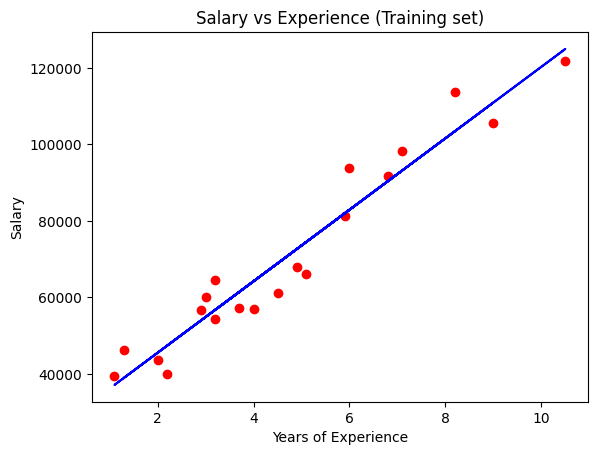

In [49]:
# Visualisation
import matplotlib.pyplot as plt
plt.scatter(X_train, Y_train, color='red')
# Reshape X_train to 2D for the predict method
plt.plot(X_train, regressor.predict(X_train.reshape(-1, 1)), color='blue')
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

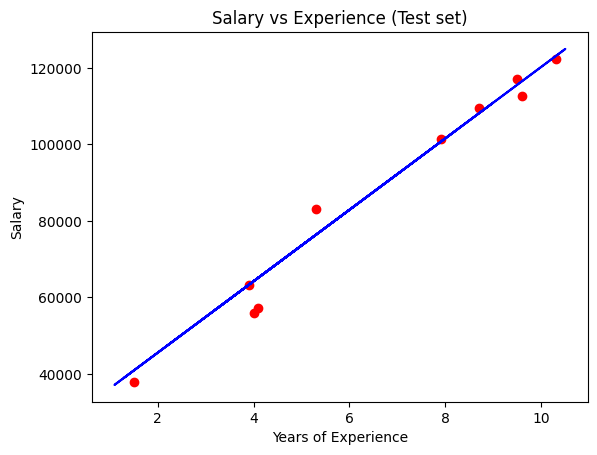

In [50]:
# Visualisation
import matplotlib.pyplot as plt
plt.scatter(X_test, Y_test, color='red')
plt.plot(X_train, regressor.predict(X_train.reshape(-1, 1)), color='blue')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

NameError: name 'reg' is not defined

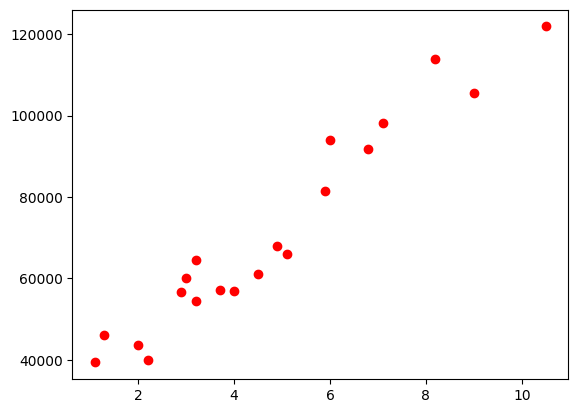

In [51]:
import matplotlib.pyplot as plt
plt.scatter(X_train, Y_train, color='red')

plt.plot(X_train, reg.predict(X_train), color='blue')
plt.title('Salary vs Experience -testset snd actual values of  y_test')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

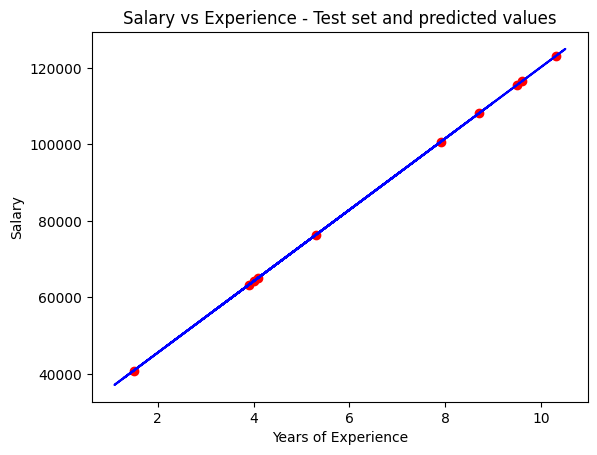

In [52]:
import matplotlib.pyplot as plt
# Fix: Use X_test instead of X_train to match the size of Y_pred (10 elements)
plt.scatter(X_test, Y_pred, color='red')

# Reshape X_train to 2D for the model's predict method
plt.plot(X_train, regressor.predict(X_train.reshape(-1, 1)), color='blue')
plt.title('Salary vs Experience - Test set and predicted values')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()